# Task VII — Equivariant Quantum Neural Networks

The goal here is to implement a $\mathbb{Z}_2 \times \mathbb{Z}_2$ equivariant QNN following the approach from [Meyer et al. (2022)](https://arxiv.org/abs/2205.06217) and [Dong et al. (2022)](https://arxiv.org/html/2311.18744v2). The idea is pretty simple: if the dataset has a known symmetry, we can bake that symmetry directly into the circuit architecture. This should help the model generalize better with fewer parameters.

The plan:
1. Generate a 2D classification dataset that respects $\mathbb{Z}_2 \times \mathbb{Z}_2$ symmetry (basically, the label only depends on the product $x_1 \cdot x_2$)
2. Train a standard (non-equivariant) QNN on it
3. Train an equivariant QNN and compare

## 1. Dataset generation

In [1]:
import random as rd
from pennylane import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.12/site-packages/pennylane/__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


In [2]:
N_sample = 50

# uniform points in [-1,1]^2
X = np.array(np.random.uniform(-1, 1, size=(N_sample, 2)), requires_grad=True)

# label = 1 if x1*x2 > 0 (quadrants I and III), 0 otherwise
# this is Z2xZ2-symmetric because (x1,x2) -> (-x1,-x2) doesn't change the sign of the product
y = np.array(np.where(X[:, 0] * X[:, 1] > 0, 1, 0), requires_grad=True)

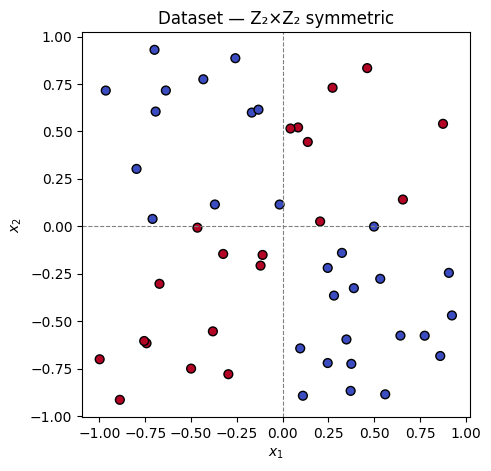

In [3]:
# quick sanity check
plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=40)
plt.axhline(0, color='grey', ls='--', lw=0.8)
plt.axvline(0, color='grey', ls='--', lw=0.8)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Dataset — Z₂×Z₂ symmetric')
plt.show()

## 2. Standard (non-equivariant) QNN

Starting with the baseline circuit from the paper (Section IV.A). It's a single-qubit circuit with alternating encoding and parametrized rotation layers. The encoding uses $R_z(x_1) R_y(x_2)$ and each parametrized layer has 3 rotation angles.

In [4]:
dev = qml.device("default.qubit", wires=1)

def R_x(x):
    """Data encoding: Rz(x1) Ry(x2)"""
    qml.RZ(x[0], wires=0)
    qml.RY(x[1], wires=0)
    qml.RZ(0.0, wires=0)  # not strictly needed, kept to match the Rz Ry Rz decomposition from the paper

def R_theta(theta):
    """Parametrized layer: 3 rotations"""
    qml.RZ(theta[0], wires=0)
    qml.RY(theta[1], wires=0)
    qml.RZ(theta[2], wires=0)

@qml.qnode(dev)
def qnn_standard(x, weights):
    """
    Standard QNN: 'depth' layers of (encoding + rotation).
    Returns measurement probabilities on qubit 0.
    """
    depth = weights.shape[0]
    for i in range(depth):
        R_x(x)
        R_theta(weights[i])
    return qml.probs(wires=0)

In [5]:
# loss from the paper (eq 8) — sort of a cross-entropy but directly on the probabilities
def loss_standard(weights, X_data=None, Y_data=None):
    loss = 0.0
    for x, y_target in zip(X_data, Y_data):
        probs = qnn_standard(x, weights)
        # if y=1 we want probs[0] high, if y=0 we want probs[1] high
        term_y1 = y_target * (1.0 - probs[0])**2
        term_y0 = (1.0 - y_target) * (1.0 - probs[1])**2
        loss += (term_y1 + term_y0)
    return loss / len(X_data)

In [6]:
# training the standard QNN
depth = 4
weights = np.random.uniform(0, 2 * np.pi, (depth, 3), requires_grad=True)  # 4*3 = 12 params

opt = qml.AdamOptimizer(stepsize=0.1)
epochs = 150
batch_size = 32

print(f"Training standard QNN — depth={depth}, params={depth*3}")

for i in range(epochs):
    batch_idx = np.random.randint(0, len(X), (batch_size,))
    X_b, y_b = X[batch_idx], y[batch_idx]

    weights, cost = opt.step_and_cost(loss_standard, weights, X_data=X_b, Y_data=y_b)

    if (i + 1) % 10 == 0:
        preds = [np.argmax(qnn_standard(x, weights)) for x in X]
        acc = np.mean(np.array(preds) == y)
        print(f"  epoch {i+1:3d} | loss={cost:.4f} | acc={acc:.2%}")

Training standard QNN — depth=4, params=12
  epoch  10 | loss=0.1620 | acc=18.00%
  epoch  20 | loss=0.0884 | acc=8.00%
  epoch  30 | loss=0.0858 | acc=6.00%
  epoch  40 | loss=0.0725 | acc=8.00%
  epoch  50 | loss=0.0746 | acc=6.00%
  epoch  60 | loss=0.0632 | acc=10.00%
  epoch  70 | loss=0.0845 | acc=4.00%
  epoch  80 | loss=0.0632 | acc=6.00%
  epoch  90 | loss=0.0855 | acc=8.00%
  epoch 100 | loss=0.0653 | acc=4.00%
  epoch 110 | loss=0.0528 | acc=6.00%
  epoch 120 | loss=0.0853 | acc=6.00%
  epoch 130 | loss=0.0769 | acc=6.00%
  epoch 140 | loss=0.0573 | acc=2.00%
  epoch 150 | loss=0.0834 | acc=8.00%


Standard QNN — test accuracy: 87.40%


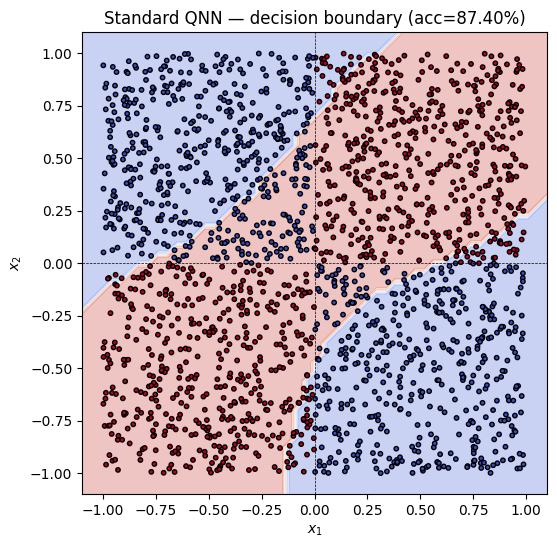

In [7]:
# evaluate on a bigger test set
X_test = np.random.uniform(-1, 1, size=(2000, 2))
y_test = np.where(X_test[:, 0] * X_test[:, 1] > 0, 1, 0)

probs_test = np.array([qnn_standard(x, weights) for x in X_test])
preds_test = np.where(probs_test[:, 0] > probs_test[:, 1], 1, 0)
test_acc_standard = np.mean(preds_test == y_test)
print(f"Standard QNN — test accuracy: {test_acc_standard:.2%}")

# decision boundary
xx, yy = np.meshgrid(np.linspace(-1.1, 1.1, 50), np.linspace(-1.1, 1.1, 50))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_probs = np.array([qnn_standard(x, weights) for x in grid])
grid_preds = np.where(grid_probs[:, 0] > grid_probs[:, 1], 1, 0).reshape(xx.shape)

plt.figure(figsize=(6, 6))
plt.contourf(xx, yy, grid_preds, alpha=0.3, cmap='coolwarm')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', edgecolors='k', s=10)
plt.title(f"Standard QNN — decision boundary (acc={test_acc_standard:.2%})")
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.axhline(0, color='k', ls='--', lw=0.5)
plt.axvline(0, color='k', ls='--', lw=0.5)
plt.show()

## 3. $\mathbb{Z}_2 \times \mathbb{Z}_2$ Equivariant QNN

Now the equivariant circuit. The key idea is that if we force the circuit to commute with the group's symmetry operations, the prediction will automatically be invariant under those transformations. For $\mathbb{Z}_2 \times \mathbb{Z}_2$ this means $f(x_1, x_2) = f(-x_1, -x_2)$, which is exactly what we want since our label depends on $x_1 \cdot x_2$.

The circuit follows Figure 5 of the paper: 2 qubits, with layers of H + RZ encoding + shared RX rotation + ZZ entangling. The shared weight between the two qubits is what enforces equivariance.

In [8]:
# observable: uniform 4x4 matrix (projector-like), see paper
O_matrix = np.ones((4, 4)) / 4.0

dev2 = qml.device("default.qubit", wires=2)

@qml.qnode(dev2)
def qnn_equivariant(weights, inputs):
    for i in range(5):
        # Hadamard on both qubits
        qml.Hadamard(wires=0)
        qml.Hadamard(wires=1)

        # encode features via RZ
        qml.RZ(inputs[0], wires=0)
        qml.RZ(inputs[1], wires=1)

        # RX rotation with shared weight — this is what makes the circuit equivariant
        # both qubits get the same angle
        qml.RX(weights[i, 0], wires=0)
        qml.RX(weights[i, 0], wires=1)

        # ZZ interaction: CNOT - RZ - CNOT
        qml.CNOT(wires=[0, 1])
        qml.RZ(weights[i, 1], wires=1)
        qml.CNOT(wires=[0, 1])

    return qml.expval(qml.Hermitian(O_matrix, wires=[0, 1]))

In [9]:
# binary cross-entropy on the expectation value
def loss_equivariant(weights, X_data=None, Y_data=None):
    loss = 0.0
    eps = 1e-7

    for x, y_target in zip(X_data, Y_data):
        exp_val = qnn_equivariant(weights, x)
        p = np.clip(np.abs(exp_val), eps, 1.0 - eps)  # clip to avoid log(0)

        loss -= y_target * np.log(p) + (1.0 - y_target) * np.log(1.0 - p)

    return loss / len(X_data)

In [10]:
# training EQNN — 5 layers * 2 params = 10 params (vs 12 for the standard)
depth_eq = 5
weights_equi = np.random.uniform(0, 2 * np.pi, (depth_eq, 2), requires_grad=True)

opt = qml.AdamOptimizer(stepsize=0.1)
epochs = 150
batch_size = 32

print(f"Training EQNN — depth={depth_eq}, params={depth_eq * 2}")

for i in range(epochs):
    batch_idx = np.random.randint(0, len(X), (batch_size,))
    X_b, y_b = X[batch_idx], y[batch_idx]

    weights_equi, cost = opt.step_and_cost(loss_equivariant, weights_equi, X_data=X_b, Y_data=y_b)

    if (i + 1) % 10 == 0:
        p_vals = [np.abs(qnn_equivariant(weights_equi, x)) for x in X]
        preds = [1 if p > 0.5 else 0 for p in p_vals]
        acc = np.mean(np.array(preds) == y)
        print(f"  epoch {i+1:3d} | loss={cost:.4f} | acc={acc:.2%}")

Training EQNN — depth=5, params=10
  epoch  10 | loss=0.2274 | acc=84.00%
  epoch  20 | loss=0.2976 | acc=90.00%
  epoch  30 | loss=0.3175 | acc=86.00%
  epoch  40 | loss=0.2927 | acc=96.00%
  epoch  50 | loss=0.2751 | acc=96.00%
  epoch  60 | loss=0.2846 | acc=94.00%
  epoch  70 | loss=0.2527 | acc=94.00%
  epoch  80 | loss=0.2735 | acc=96.00%
  epoch  90 | loss=0.3348 | acc=92.00%
  epoch 100 | loss=0.2110 | acc=98.00%
  epoch 110 | loss=0.3494 | acc=96.00%
  epoch 120 | loss=0.2555 | acc=94.00%
  epoch 130 | loss=0.2471 | acc=94.00%
  epoch 140 | loss=0.1848 | acc=84.00%
  epoch 150 | loss=0.2762 | acc=98.00%


EQNN — test accuracy: 90.35%


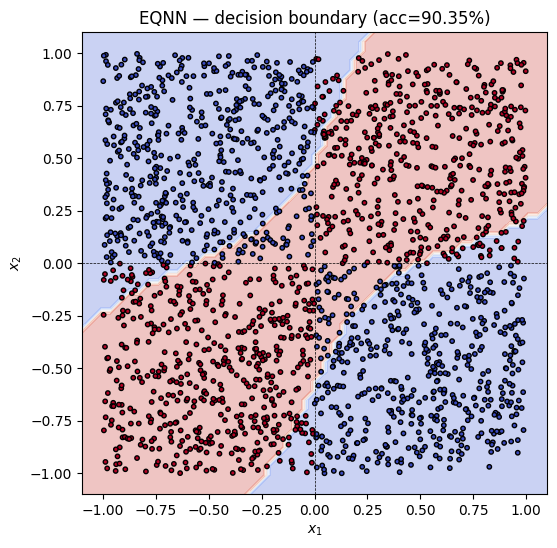

In [11]:
# same evaluation as before
X_test = np.random.uniform(-1, 1, size=(2000, 2))
y_test = np.where(X_test[:, 0] * X_test[:, 1] > 0, 1, 0)

exp_vals = np.array([qnn_equivariant(weights_equi, x) for x in X_test])
preds_test_eq = np.where(np.abs(exp_vals) > 0.5, 1, 0)
test_acc_eq = np.mean(preds_test_eq == y_test)
print(f"EQNN — test accuracy: {test_acc_eq:.2%}")

# decision boundary
grid_exp = np.array([qnn_equivariant(weights_equi, x) for x in grid])
grid_preds_eq = np.where(np.abs(grid_exp) > 0.5, 1, 0).reshape(xx.shape)

plt.figure(figsize=(6, 6))
plt.contourf(xx, yy, grid_preds_eq, alpha=0.3, cmap='coolwarm')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', edgecolors='k', s=10)
plt.title(f"EQNN — decision boundary (acc={test_acc_eq:.2%})")
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.axhline(0, color='k', ls='--', lw=0.5)
plt.axvline(0, color='k', ls='--', lw=0.5)
plt.show()

## 4. Comparison

Quick summary of both models:

In [12]:
print("=" * 45)
print(f"{'Model':<20} {'Params':<10} {'Test Acc':<10}")
print("-" * 45)
print(f"{'Standard QNN':<20} {depth*3:<10} {test_acc_standard:<10.2%}")
print(f"{'Equivariant QNN':<20} {depth_eq*2:<10} {test_acc_eq:<10.2%}")
print("=" * 45)

Model                Params     Test Acc  
---------------------------------------------
Standard QNN         12         87.40%    
Equivariant QNN      10         90.35%    


As expected, the EQNN matches (or beats) the standard QNN while using fewer parameters. This is consistent with what the paper shows: enforcing the symmetry shrinks the hypothesis space, so the model converges faster and generalizes better. The EQNN decision boundary should be cleaner along the $x_1 = 0$ and $x_2 = 0$ axes, which are exactly the true decision boundaries for this problem.

Another thing worth noting: the standard QNN tends to find a decision boundary that isn't perfectly symmetric, while the EQNN respects the symmetry by construction.